# Backgrounds at LUXE's IP

In [1]:
import os
os.chdir('/Users/marindeniaud/PhD/PhD-git/luxe-elbex')

import numpy as _np
import matplotlib.pyplot as _plt
import pybdsim as _bd
import subprocess as _sub

from manchester_farm.background import beamGas
from manchester_farm.background import G4Dict

initializing ocelot...


### Date and save prefix

In [2]:
date = "2026_06_29"
save_name_prefix = "jupyter_notebooks/plots/EUXFEL/Background/" + date + "_EuXFEL_plot"

## Test optics match

In [ ]:
gmadfile   = 'manchester_farm/background/gmad_files/XTD8_matched_test_biasing.gmad'
outputfile = 'manchester_farm/background/gmad_files/test_for_table.root'
opticsfile = 'manchester_farm/background/gmad_files/test_for_table_optics.root'

In [ ]:
_bd.Run.RebdsimOptics(outputfile, opticsfile)

In [ ]:
from xsuite_scripts import XTD8_no_DBA_match_with_no_R56 as XTD8_matched_Xsuite

In [ ]:
_bd.Compare.XsuiteVsBDSIM(XTD8_matched_Xsuite, 'XTD8', opticsfile, surveyfile=None, 
                          energySpread=6e-4, ex=3.58e-11, ey=3.58e-11)

In [ ]:
beamGas.convertRootOutputToHistograms("gmad_files/output.root", angle_cut=1e-3)

## Backgrounds

In [3]:
mergedhistfile = "manchester_farm/background/results/mergedfiles/51000000_part_XTD8_background_1e-12_merged.root"

REBDSIMCOMBINE analysis file - using RebdsimFile
REBDSIMCOMBINE analysis file - using RebdsimFile
REBDSIMCOMBINE analysis file - using RebdsimFile
REBDSIMCOMBINE analysis file - using RebdsimFile
REBDSIMCOMBINE analysis file - using RebdsimFile
REBDSIMCOMBINE analysis file - using RebdsimFile


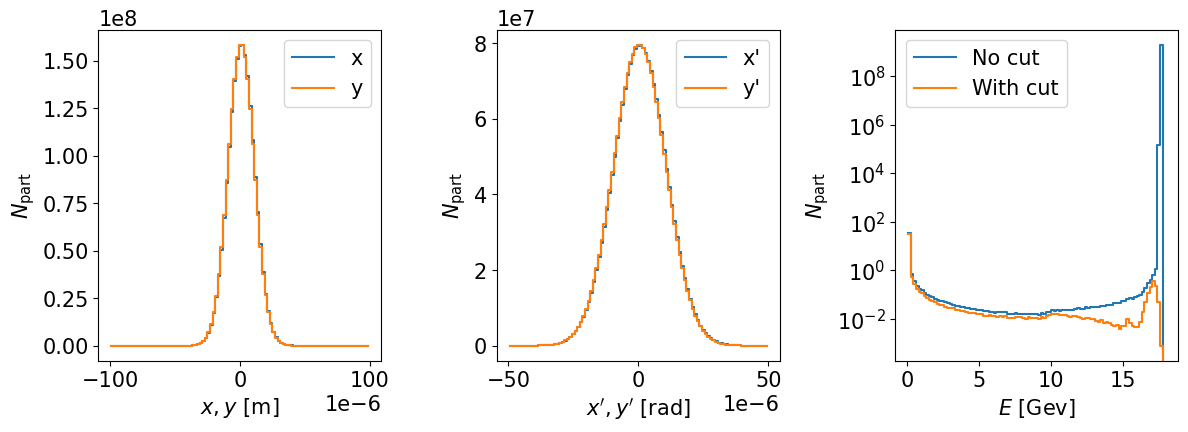

In [4]:
beamGas.plotSamplerSubplots(mergedhistfile, "D2890L", particle='all', figsize=[12, 5])
_plt.gcf().suptitle('', fontsize=15)
os.chdir('/Users/marindeniaud/PhD/PhD-git/luxe-backgrounds/06_analysis/')
_plt.savefig("{}_Histograms_LUXE_IP_all.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')
os.chdir('/Users/marindeniaud/PhD/PhD-git/luxe-elbex')

REBDSIMCOMBINE analysis file - using RebdsimFile
REBDSIMCOMBINE analysis file - using RebdsimFile
REBDSIMCOMBINE analysis file - using RebdsimFile
BDSIM output file - using DataLoader
BDSIM output file - using DataLoader


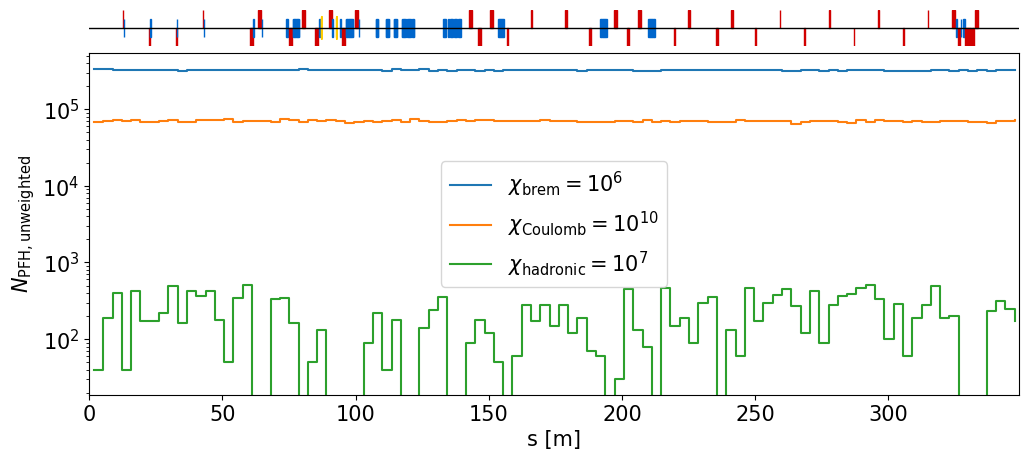

In [31]:
beamGas.plotMultipleHistograms(mergedhistfile, ["PFH_S_fBremsstrahlung", "PFH_S_fCoulombScattering", "PFH_S_fHadronInelastic"], 
                               gmadfile = 'gmad_files/XTD8_matched_biasing.gmad', 
                               xlabel= r"s [m]", ylabel=r"$N_{\rm PFH, unweighted}$", logY=True, figsize=[12, 5], xlim=None)
fig = _plt.gcf()
fig.axes[0].legend([r"$\chi_{\rm brem} = 10^{6}$", r"$\chi_{\rm Coulomb} = 10^{10}$", r"$\chi_{\rm hadronic} = 10^{7}$"])
os.chdir('/Users/marindeniaud/PhD/PhD-git/luxe-backgrounds/06_analysis/')
_plt.savefig("{}_PFH_all_processes_50m.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')
os.chdir('/Users/marindeniaud/PhD/PhD-git/luxe-elbex')

REBDSIMCOMBINE analysis file - using RebdsimFile


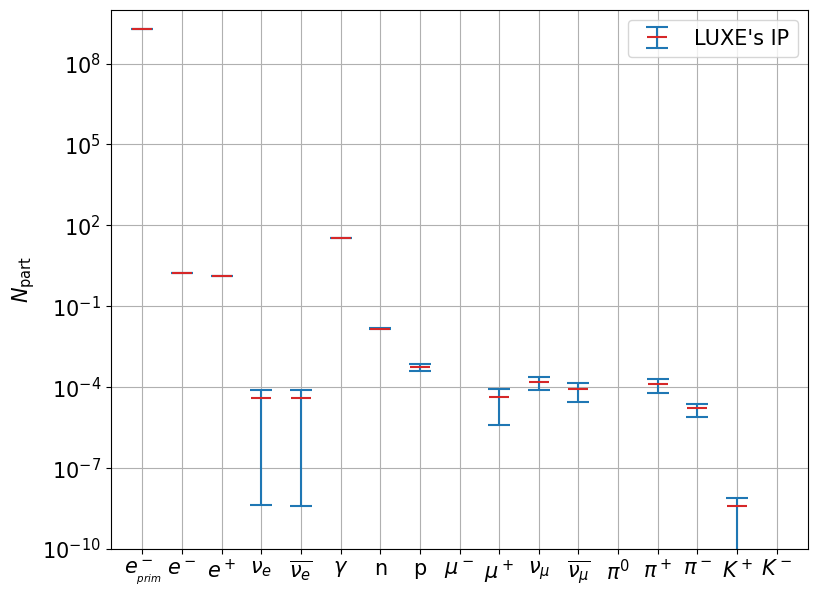

In [4]:
beamGas.plotHistogram(mergedhistfile, "D2890L_partID", errorbars=True, partlabels=True, logY=True, samefig=False, figsize=[9, 7])
_plt.legend(["LUXE's IP"])
_plt.ylim([1e-10, 1e10])
os.chdir('/Users/marindeniaud/PhD/PhD-git/luxe-backgrounds/06_analysis/')
_plt.savefig("{}_Particle_species_at_LUXE_IP.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')
os.chdir('/Users/marindeniaud/PhD/PhD-git/luxe-elbex')

In [95]:
histfile = _bd.Data.Load(mergedhistfile)
data = histfile.histogramspy
samplername = "D2890L"
histname = "Event/MergedHistograms/{}_partID".format(samplername)
hist = data[histname]

REBDSIMCOMBINE analysis file - using RebdsimFile


In [104]:
partname = 'proton'
partID = getPartID(partname)
ID = beamGas.partID_hist_dict[partID]
hist.contents[ID]

np.float64(0.000545070201538915)

In [82]:
from xsuite_scripts import XTD8_no_DBA_match_with_no_R56 as XTD8_matched_Xsuite

In [80]:
def getPartID(name, d=G4Dict.Particle_type_dict):
    for partID in d:
        if name == d[partID]['Name']:
            return partID
        
        
def getSymbol(name, d=G4Dict.Particle_type_dict):
    for partID in d:
        if name == d[partID]['Name']:
            return d[partID]['Symbol']

In [89]:
dict_name_s = {}
survey = XTD8_matched_Xsuite.env.XTD8.survey()
for i in range(len(survey)):
    name = survey.name[i].replace('.', '').replace('::', '_').replace('_0', '')
    dict_name_s[name] = survey.s[i]+survey.length[i]

REBDSIMCOMBINE analysis file - using RebdsimFile
BDSIM output file - using DataLoader
BDSIM output file - using DataLoader


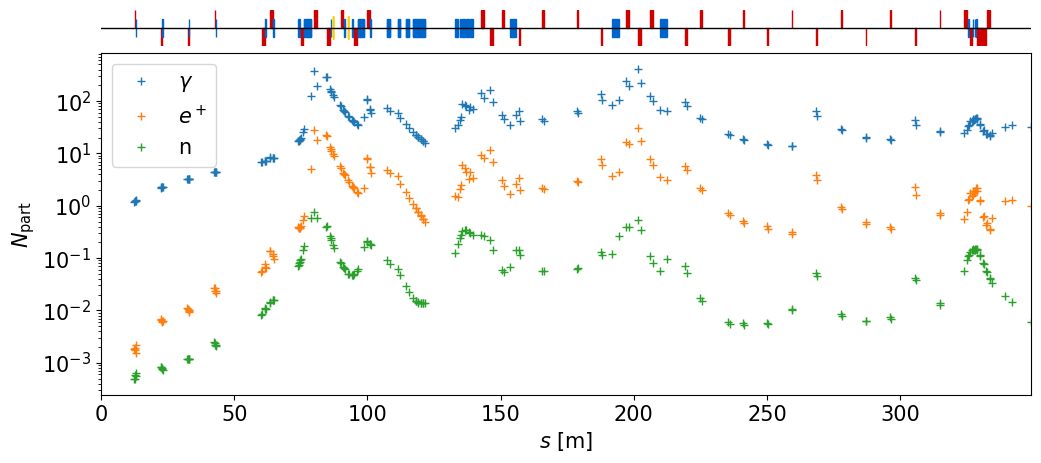

In [92]:
histfile = _bd.Data.Load(mergedhistfile)
data = histfile.histogramspy
_plt.figure(figsize=[12, 5])
for partname in ['photon', 'positron', 'neutron']:
    s = []
    part = []
    partID = getPartID(partname)
    ID = beamGas.partID_hist_dict[partID]
    for samplername in dict_name_s.keys():
        histname = "Event/MergedHistograms/{}_partID".format(samplername)
        try:
            hist = data[histname]
            s.append(dict_name_s[samplername])
            part.append(_np.sum(hist.contents[ID]))
        except KeyError:
            # print(samplername)
            pass
    _plt.plot(s, part, '+', label=getSymbol(partname))
_plt.legend()
_plt.semilogy()
_plt.ylabel(r"$N_{\rm part}$")
_plt.xlabel(r"$s$ [m]")
beamGas.addMachineLattice('gmad_files/XTD8_matched_biasing.gmad')
os.chdir('/Users/marindeniaud/PhD/PhD-git/luxe-backgrounds/06_analysis/')
_plt.savefig("{}_Particle_per_species_along_s.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')
os.chdir('/Users/marindeniaud/PhD/PhD-git/luxe-elbex')